### Jointplot: Magnitude vs Depth

- Shows the relationship between earthquake magnitude and depth.
- Each point represents an individual earthquake event.
- Helps identify patterns and trends in the dataset.
- Useful for detecting possible correlations between magnitude and depth.
- Supports exploratory data analysis (EDA) of earthquake data.

                               time  latitude  longitude  depth  mag  \
0  1976-01-02 06:27:46.700000+00:00    36.381     71.245   93.0  5.0   
1  1976-01-02 13:46:45.600000+00:00    39.380     73.161   33.0  4.8   
2         1976-01-06 23:35:12+00:00    33.913     94.325   33.0  4.7   
3  1976-01-07 00:24:54.100000+00:00    32.854     75.964   50.0  5.4   
4  1976-01-08 06:25:11.500000+00:00    36.344     70.914  116.0  4.8   

                                  place  year  month  hour   mag_bin  \
0    42 km SW of Ashk?sham, Afghanistan  1976      1     6  Moderate   
1  79 km ESE of Kyzyl-Eshme, Kyrgyzstan  1976      1    13  Moderate   
2               Southern Qinghai, China  1976      1    23  Moderate   
3         26 km ESE of Bhadarw?h, India  1976      1     0    Strong   
4          58 km S of Jurm, Afghanistan  1976      1     6  Moderate   

      depth_bin  
0  Intermediate  
1       Shallow  
2       Shallow  
3       Shallow  
4  Intermediate  


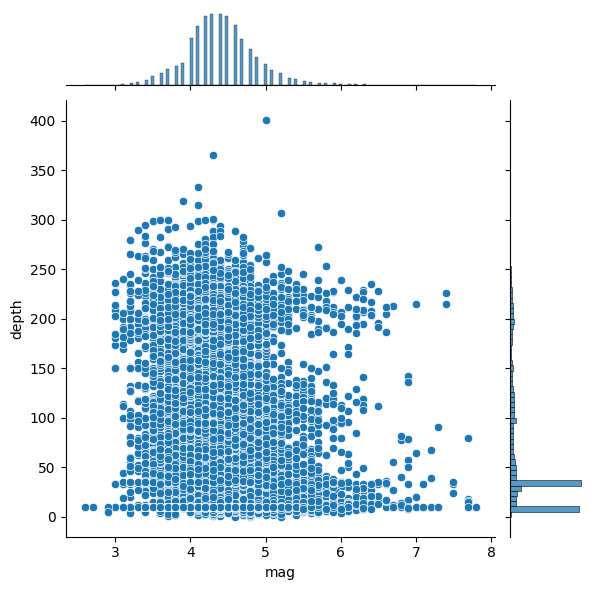

In [ ]:
from pathlib import Path
# Project root (two levels up)
# If running as script
try:
    project_root = Path(__file__).resolve().parent.parent
except NameError:
    # If in Jupyter/interactive mode
    project_root = Path.cwd().parent

# Paths
data_path = project_root / "data" / "earthquakes_cleaned.csv"
image_path = project_root / "images"

import pandas as pd
df = pd.read_csv(data_path)
print(df.head())
import seaborn as sns
import matplotlib.pyplot as plt

sns.jointplot(
    data= pd.read_csv(data_path),
    x='mag',
    y='depth',
    kind='scatter'
)


plt.savefig(f"{image_path}/jointplot.png")
plt.show()

### Heatmap

- Displays the correlation between different earthquake features.
- Uses color intensity to represent the strength of relationships.
- Helps identify highly correlated variables.
- Useful for feature selection and pattern discovery.
- Makes complex relationships easier to understand visually.

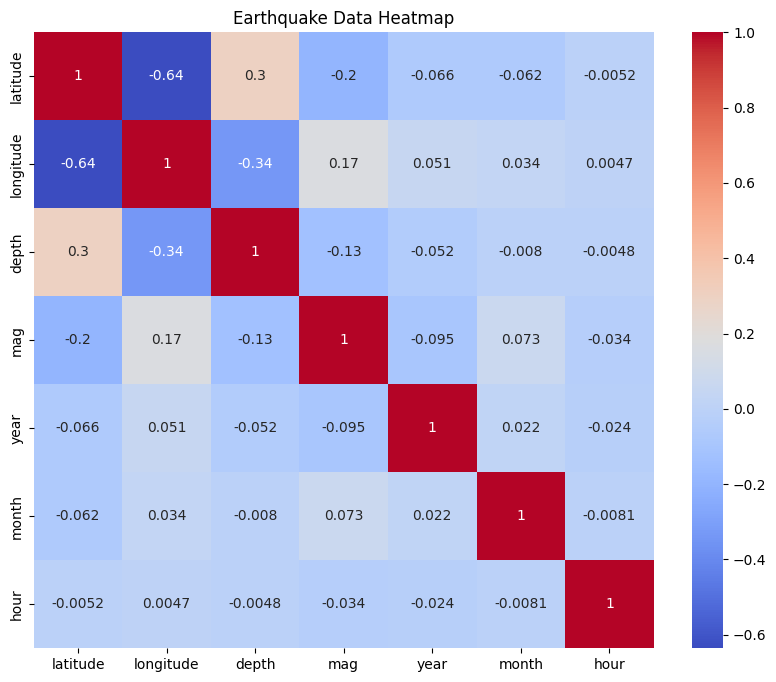

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Earthquake Data Heatmap")
plt.savefig(f"{image_path}/heatmap.png")
plt.show()


### Pairplot

- Displays pairwise relationships between multiple numerical features.
- Helps compare variables simultaneously.
- Useful for identifying correlations and distributions.
- Reveals patterns, clusters, and potential outliers.
- Provides a comprehensive overview of the dataset.

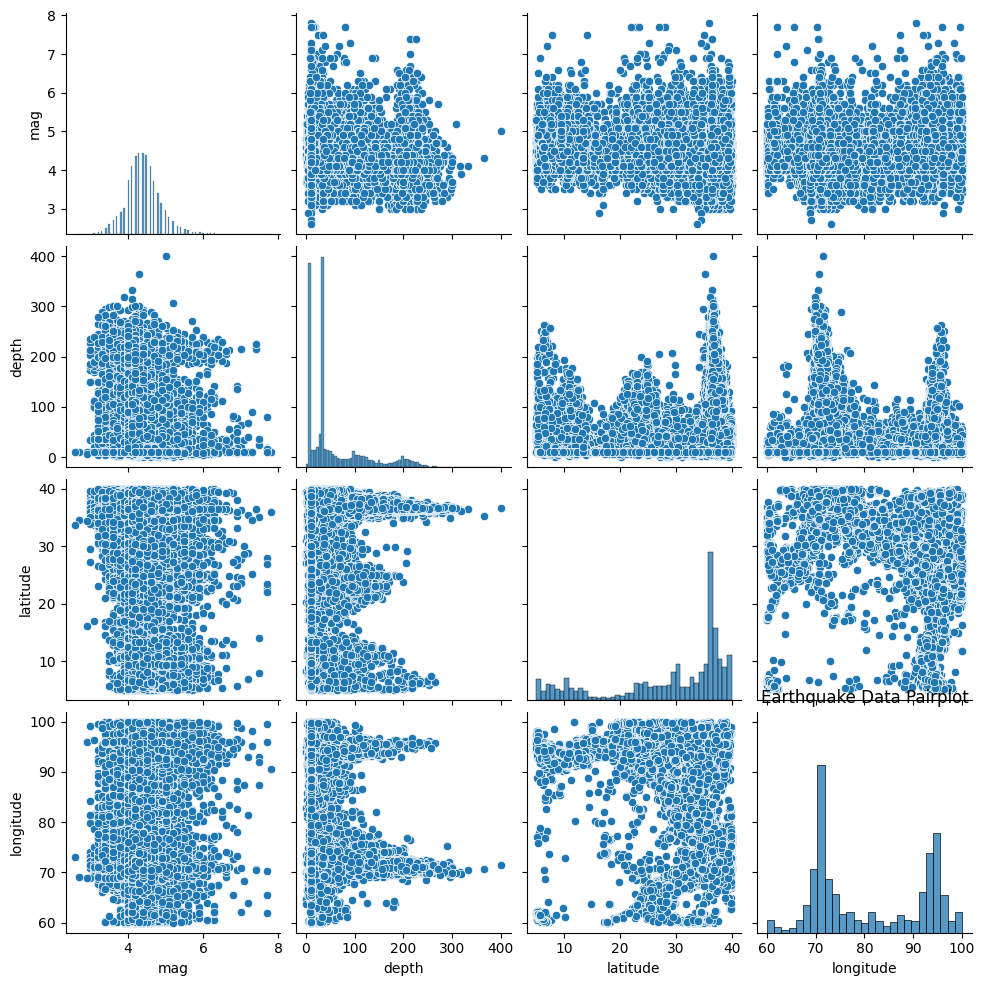

In [ ]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

sns.pairplot(
   df[["mag","depth","latitude","longitude"]]
)
plt.title("Earthquake Data Pairplot")

plt.savefig(f"{image_path}/pairplot.png")
plt.show()


### Scatter Plot

- Visualizes the relationship between two numerical variables.
- Each point represents an individual earthquake event.
- Helps identify trends, clusters, and outliers.
- Useful for detecting correlations between variables.
- Supports exploratory data analysis (EDA).

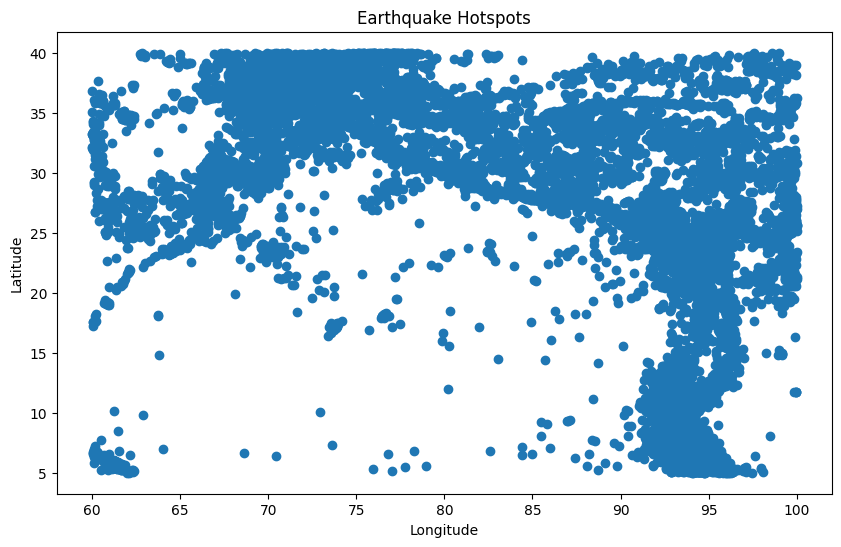

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(10,6))


plt.scatter(
    df["longitude"],
    df["latitude"]
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Earthquake Hotspots")
plt.savefig(f"{image_path}/scatterplot.png")
plt.show()


### Timeline Graph

- Shows earthquake occurrences over time.
- Helps analyze trends and patterns across different periods.
- Useful for identifying periods of high seismic activity.
- Enables time-based comparison of earthquake events.
- Supports temporal analysis of the dataset.

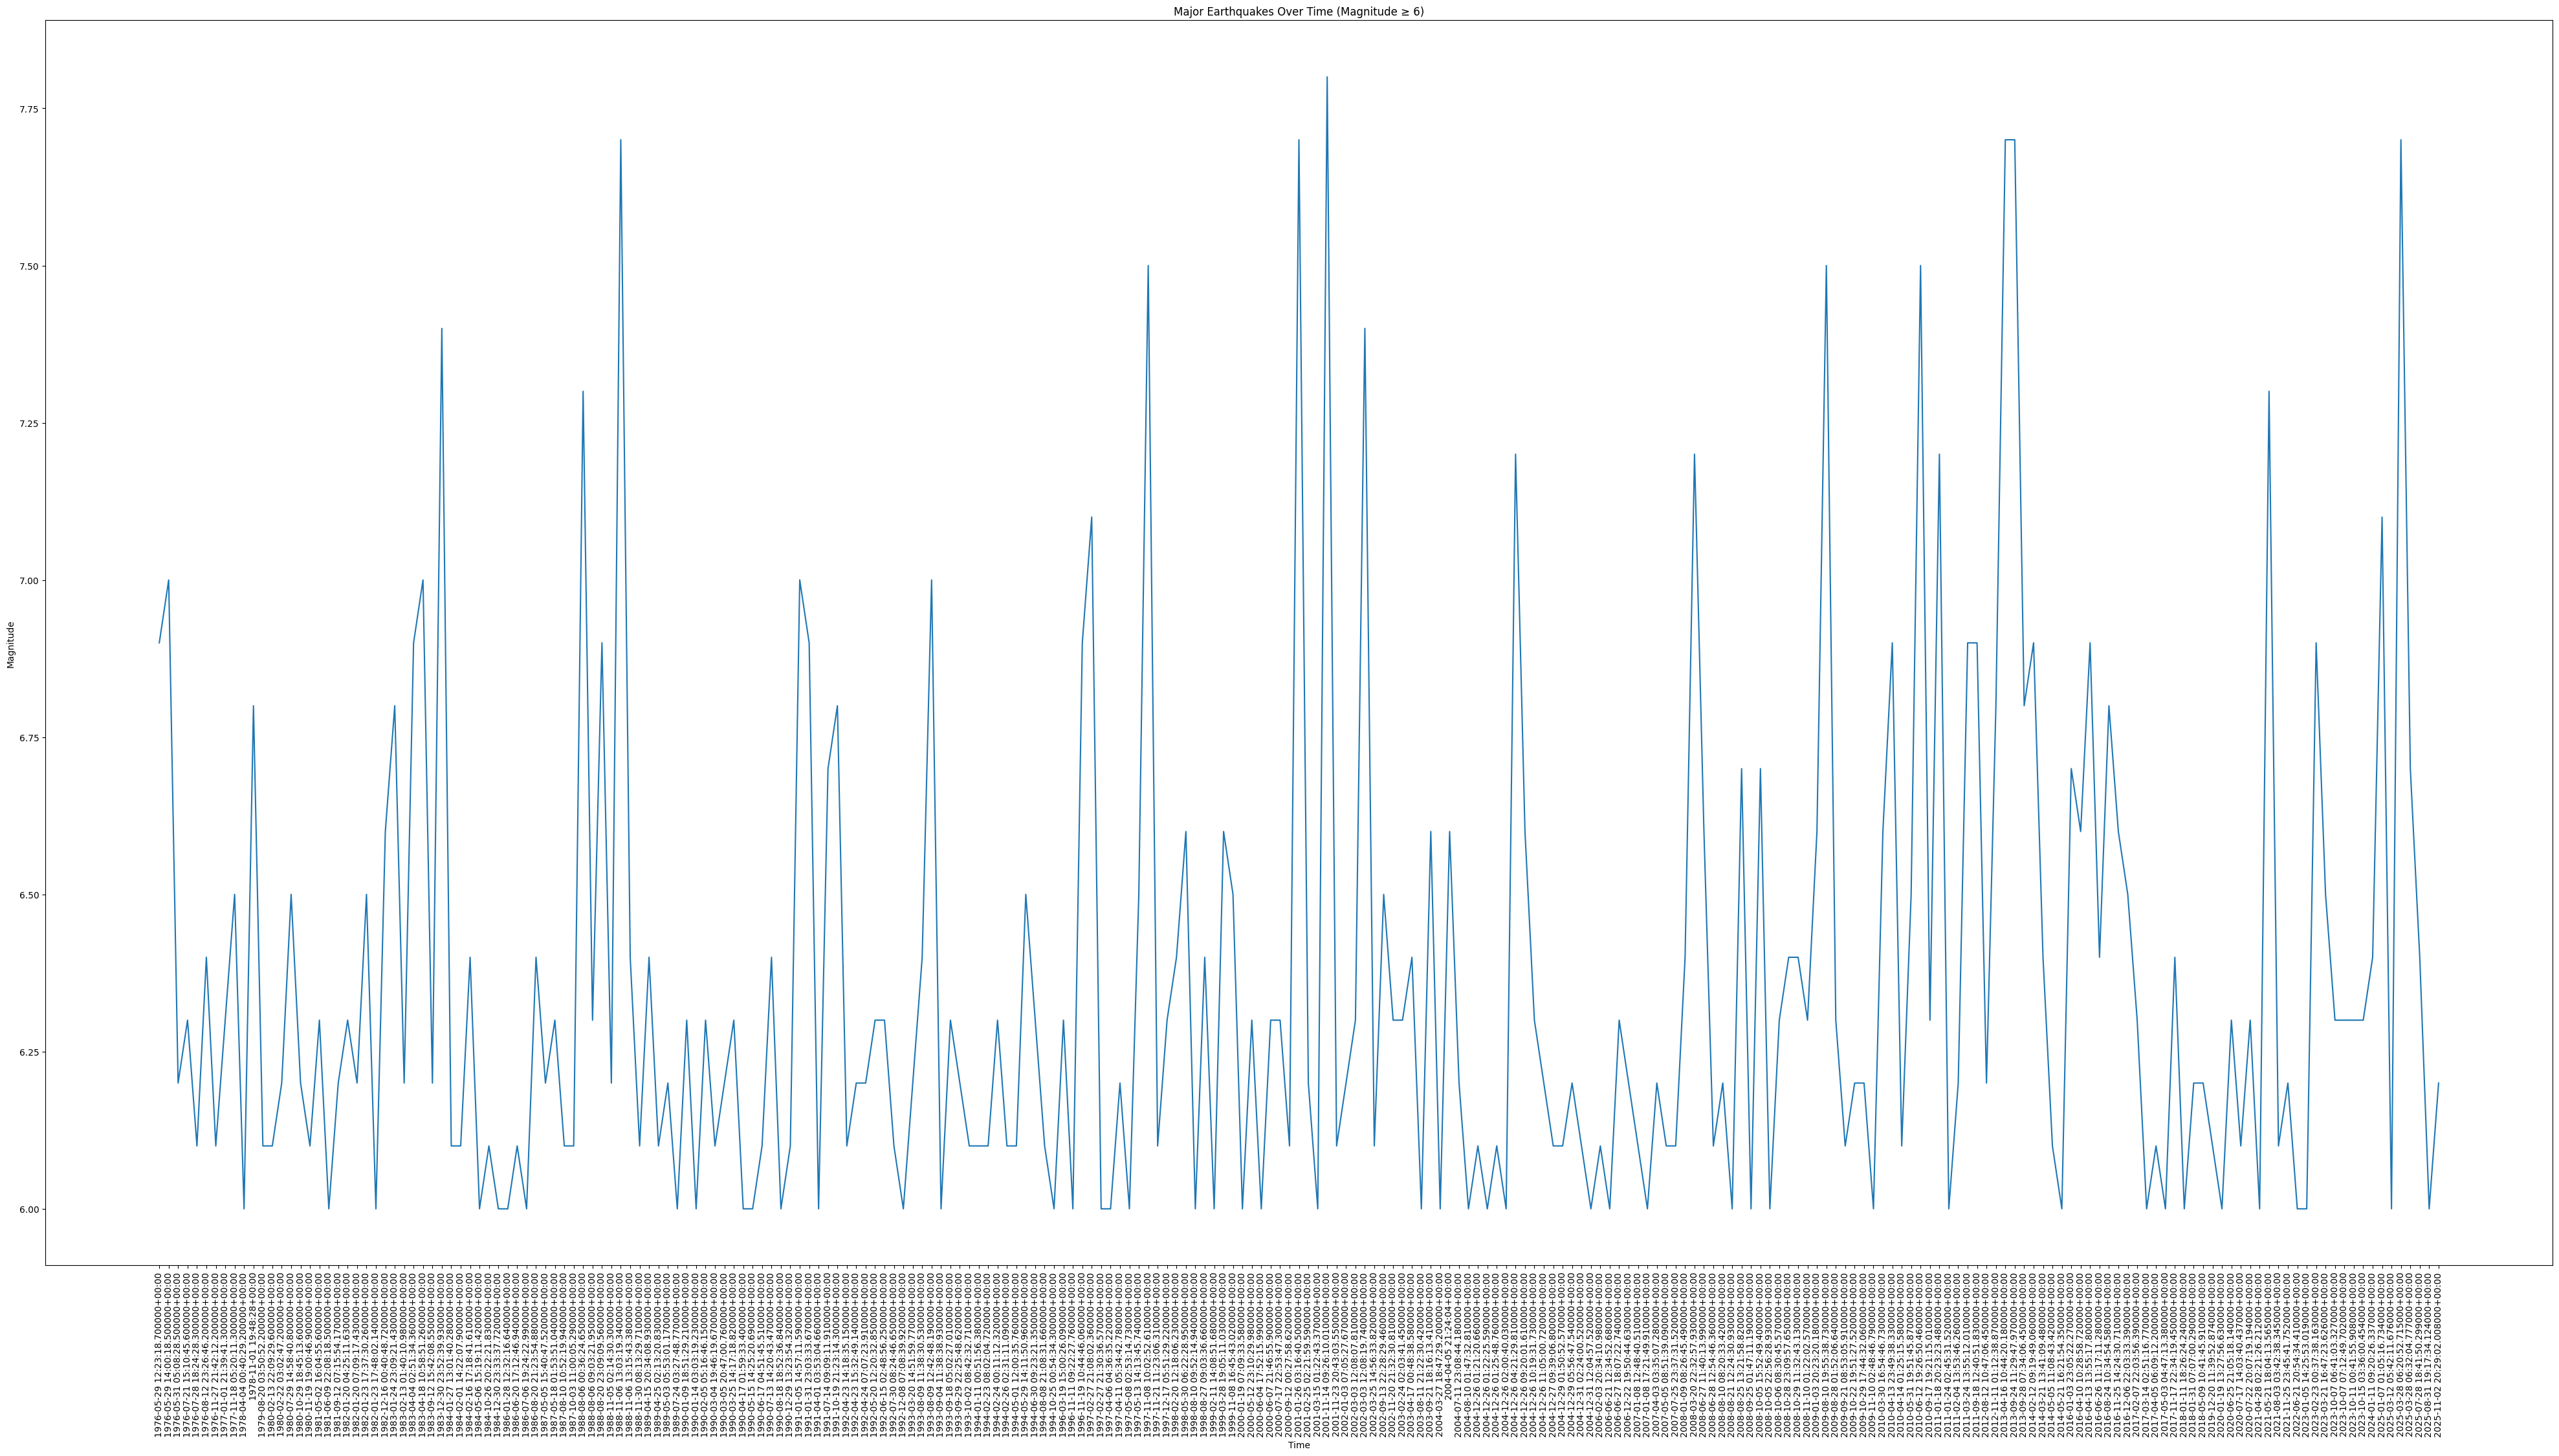

In [ ]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

df_major = df[df["mag"] >= 6]

plt.figure(figsize=(50,25))

plt.plot(
    df_major["time"],
    df_major["mag"]
)

plt.xlabel("Time")
plt.ylabel("Magnitude")
plt.title("Major Earthquakes Over Time (Magnitude ≥ 6)")

plt.xticks(rotation=90)
plt.savefig(f"{image_path}/timeplot.png")
plt.show()


### Bar Plot

- Visualizes the distribution of earthquake events across categories.
- Allows quick comparison of earthquake counts.
- Highlights patterns and differences in the dataset.
- Helps identify dominant categories or ranges.
- Supports effective exploratory data analysis (EDA).

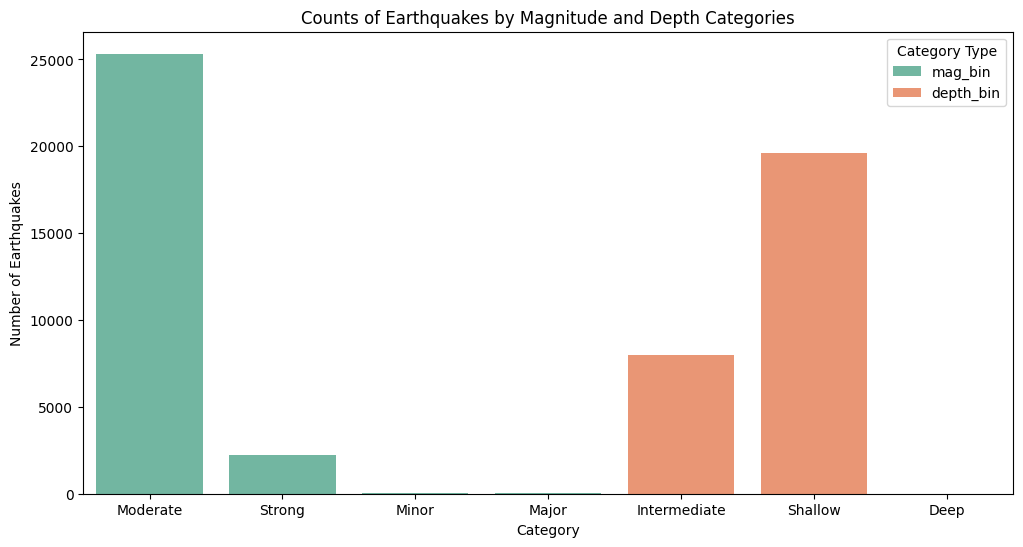

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Melt the dataframe to long format for categories
df_melted = df.melt(
    value_vars=["mag_bin", "depth_bin"],
    var_name="CategoryType",
    value_name="Category"
)

plt.figure(figsize=(12,6))
sns.countplot(data=df_melted, x="Category", hue="CategoryType", palette="Set2")

plt.title("Counts of Earthquakes by Magnitude and Depth Categories")
plt.xlabel("Category")
plt.ylabel("Number of Earthquakes")
plt.legend(title="Category Type")
plt.savefig(f"{image_path}/barplot.png")
plt.show()


### Histogram

- Shows the distribution of a numerical variable.
- Displays the frequency of data within different ranges.
- Helps identify patterns and outliers.
- Useful for understanding data spread and shape.
- Supports exploratory data analysis (EDA).

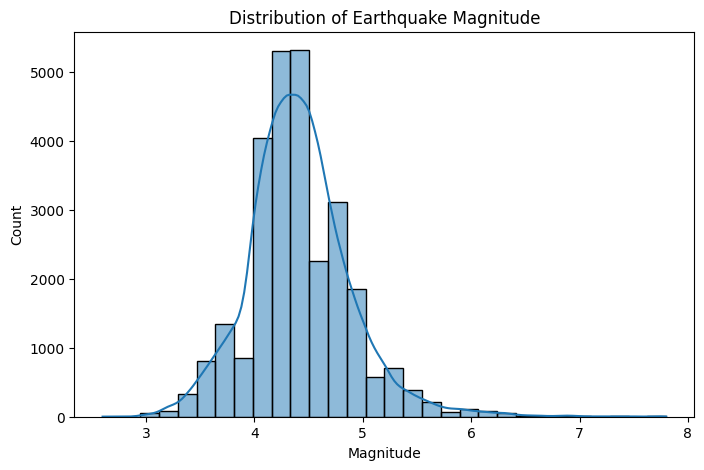

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(8,5))

sns.histplot(df['mag'], bins=30, kde=True)


plt.title("Distribution of Earthquake Magnitude")
plt.xlabel("Magnitude")
plt.ylabel("Count")
plt.savefig(f"{image_path}/histogram.png")

plt.show()